In [44]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import nifty8 as ift
import numpy as np
import resolve as rve

from copy import deepcopy
from scipy.signal import convolve


from aim_resolve import Observation, SignalSpace, plot_arrays, check_type

jax.config.update("jax_enable_x64", True)

In [52]:
def build_exact_responses(obs, space):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l


def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val


def compute_noise_kernel(RNR, relativ_min_val=0.):
    '''Build the inverse noise kernel for the given RNR operator.'''
    dom = RNR.domain
    shp = dom.shape
    FFT = ift.FFTOperator(RNR.domain)

    delta = np.zeros(shp)
    delta[shp[0]//2, shp[1]//2] = 1 / dom.scalar_weight()
    delta = ift.makeField(dom, delta)
    kernel = RNR(delta).val
    kernel = np.roll(kernel, -shp[0]//2, axis=0)
    kernel = np.roll(kernel, -shp[1]//2, axis=1)
    kernel = ift.makeField(RNR.target, kernel)
    FFT = ift.FFTOperator(RNR.domain)
    max_val = np.max(FFT(kernel).abs().val)
    min_val = relativ_min_val * max_val
    min_val = ift.full(FFT.target, min_val)
    min_val_adder = ift.Adder(min_val)

    pos_eig_val = ift.Operator.identity_operator(FFT.target).exp()
    pos_eig_val = min_val_adder @ pos_eig_val
    rls1 = ift.Realizer(pos_eig_val.target)
    rls2 = ift.Realizer(FFT.domain)

    kernel_pos = rls2 @ FFT.inverse @ rls1.adjoint @ pos_eig_val

    cov = ift.ScalingOperator(kernel_pos.target, 1e-2*max_val)
    lh = ift.GaussianEnergy(data=kernel, inverse_covariance=cov.inverse) @ kernel_pos
    init_pos = (FFT(kernel) - min_val).abs().log()
    energy = ift.EnergyAdapter(position=init_pos, op=lh, want_metric=True)

    ic_newton = ift.DeltaEnergyController(name='Newton', iteration_limit=80, tol_rel_deltaE=0)
    minimizer = ift.NewtonCG(ic_newton)
    res = minimizer(energy)[0].position

    return pos_eig_val(res).val


def fft_fun(space):
    check_type(space, SignalSpace)
    dvol = space.dis.prod()
    print('dvol:', dvol)
    return lambda x: dvol * jnp.fft.fftn(x)


def ifft_fun(space):
    check_type(space, SignalSpace)
    dvol = 1. / (space.shp * space.dis).prod()
    print('dvol:', dvol)
    npix = space.size
    print('npix:', npix)
    return lambda x: dvol * npix * jnp.fft.ifftn(x)


def shift_kernel(kernel):
    shifted_kernel = np.roll(kernel, -kernel.shape[0]//2, axis=0)
    shifted_kernel = np.roll(shifted_kernel, -kernel.shape[1]//2, axis=1)
    return shifted_kernel


def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(-1, factor).mean(axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    
def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def ensure_list(x):
    if isinstance(x, (type({}.keys()), type({}.values()))):
        return list(x)
    elif isinstance(x, (list, tuple, set)):
        return list(x)
    else:
        return [x]



def plot_1d(arrays, labels=None, *, figsize=(5,2), norm='linear', title='', offset=1, vmin=None, vmax=None, cmap='Paired'):    
    arrays = ensure_list(arrays)
    labels = ensure_list(labels) if labels is not None else [None]*len(arrays)

    plt.figure(figsize=figsize)
    colors = plt.colormaps.get_cmap(cmap)

    if norm == 'log':
        min_a = min([a[a > 0].min() for a in arrays if np.any(a > 0)])
    for i, (a,l) in enumerate(zip(arrays, labels)):
        if a.size != arrays[0].size:
            raise ValueError("All arrays must have the same size")
        a = np.array(a)
        if norm == 'log':
            a[a <= 0] = min_a
        if offset:
            a = a[offset:-offset]
        plt.plot(np.arange(a.size), a, color=colors(i), label=l if l else None)

    if any(labels):
        plt.legend()
    plt.yscale(norm)
    if vmin is not None or vmax is not None:
        plt.ylim(vmin, vmax)
    plt.title(title)
    plt.show()

In [4]:
obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()
print(obs)

Observation:
  Source name:		None
  Visibilities shape:	(1, 3668965, 7)
  # visibilities:	25682755
  Frequency range:	986.720 -- 1137.188 MHz
  Polarizations:	I
  Shortest baseline:	0.0 m -> inf deg
  Longest baseline:	7697.6 m -> 7.064 arcsec
  Flagged:		38.1%


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/resolve/data/observation.py:754: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


SignalSpace(shape=(512, 512), distances=(3.408846195301425e-05, 3.408846195301425e-05), center=(0.0, 0.0), rotation=0.0)


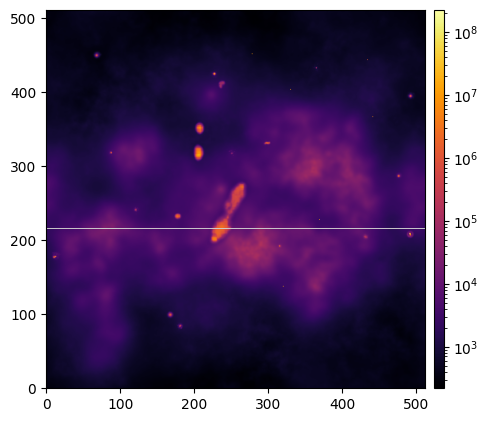

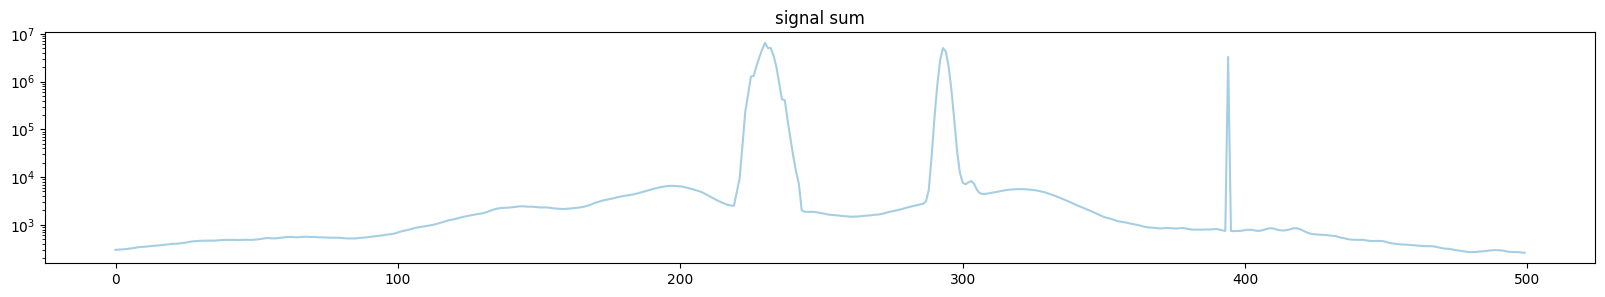

In [128]:
fname = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_rec.pkl'
sky_2d_512 = np.load(fname, allow_pickle=True)[0]
space_2d_512 = SignalSpace.build(shape=sky_2d_512.shape, fov=('1deg', '1deg'))
print(space_2d_512)

slc = 215 #207
signal_slc = sky_2d_512.copy()
signal_slc[:, slc] = np.nan
plot_arrays(signal_slc, norm='log', dpi=100)


signal_bg = sky_2d_512[140, :]

peak = sky_2d_512[:, 215]
peak = np.log(peak) - 9.5
peak = np.where(peak > 0, peak, 0)
# plot_1d(peak)

slc_t0 = slice(200, 264)
signal_t0 = np.zeros_like(peak)
signal_t0[slc_t0] = peak[200:264]
signal_t0 = np.exp(signal_t0 * 3)

slc_t1 = slice(270, 334)
signal_t1 = np.zeros_like(peak)
signal_t1[slc_t1] = peak[260:324]
signal_t1 = np.exp(signal_t1 * 15)

idx_p0 = 400
ps_ker = 15
signal_p0 = np.zeros_like(peak)
signal_p0[idx_p0] = np.exp(15)

signal_sum = signal_bg + signal_t0 + signal_t1 + signal_p0
plot_1d(signal_sum, norm='log', title='signal sum', offset=6, figsize=(20,3))

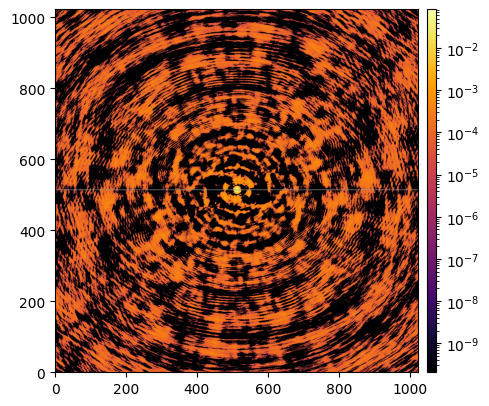

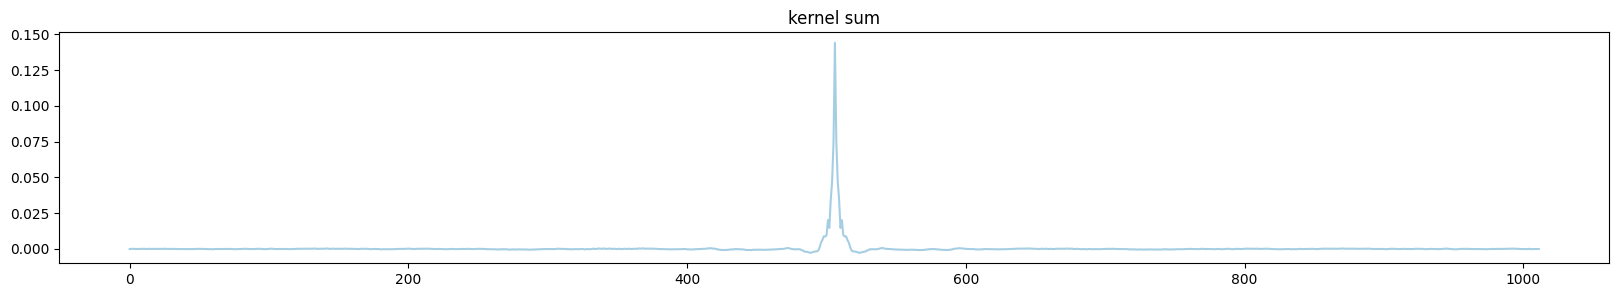

In [65]:
R, R_l, RNR, RNR_l = build_exact_responses(obs, space_2d_512)

psf_kernel_2d_512 = compute_psf_kernel(RNR_l)

slc = 512 #207
psf_kernel_slc = psf_kernel_2d_512.copy()
psf_kernel_slc[:, slc] = np.nan
plot_arrays(psf_kernel_slc, norm='log', dpi=100)

kernel_sum = psf_kernel_2d_512[:, slc]

plot_1d(kernel_sum, norm='linear', title='kernel sum', offset=6, figsize=(20,3))

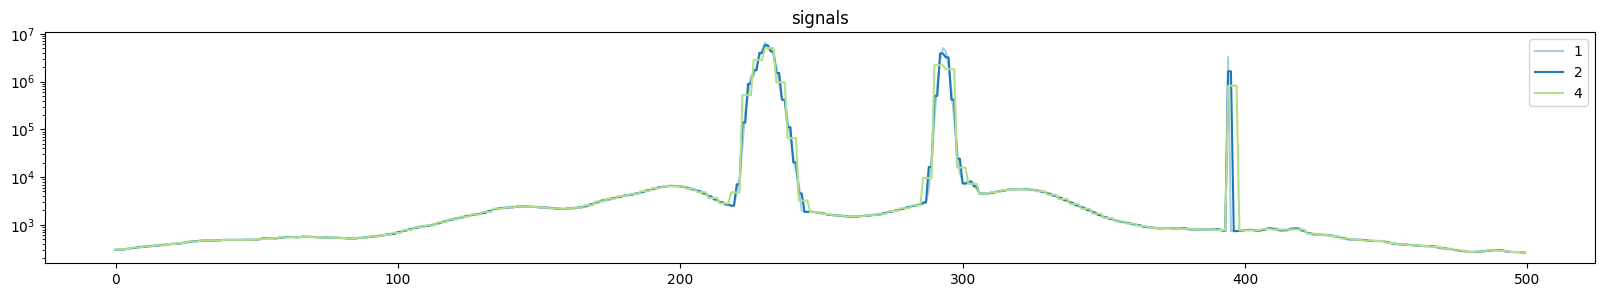

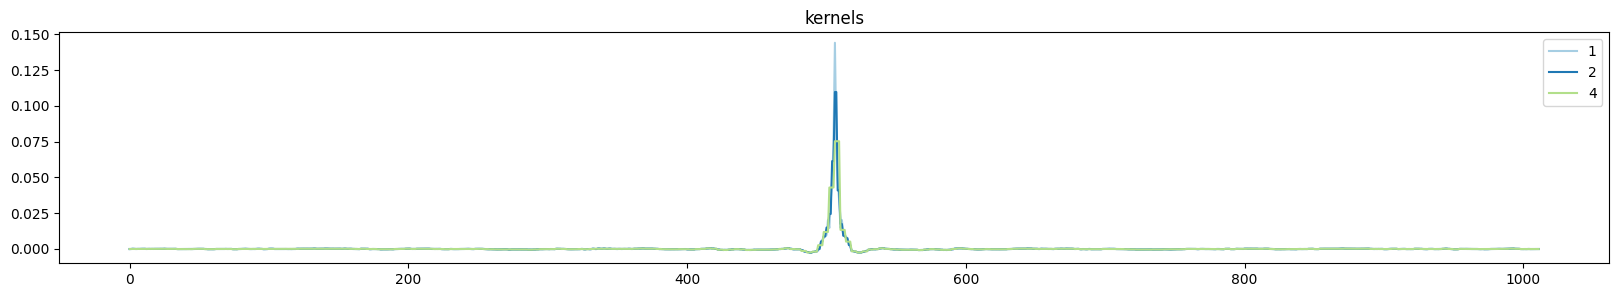

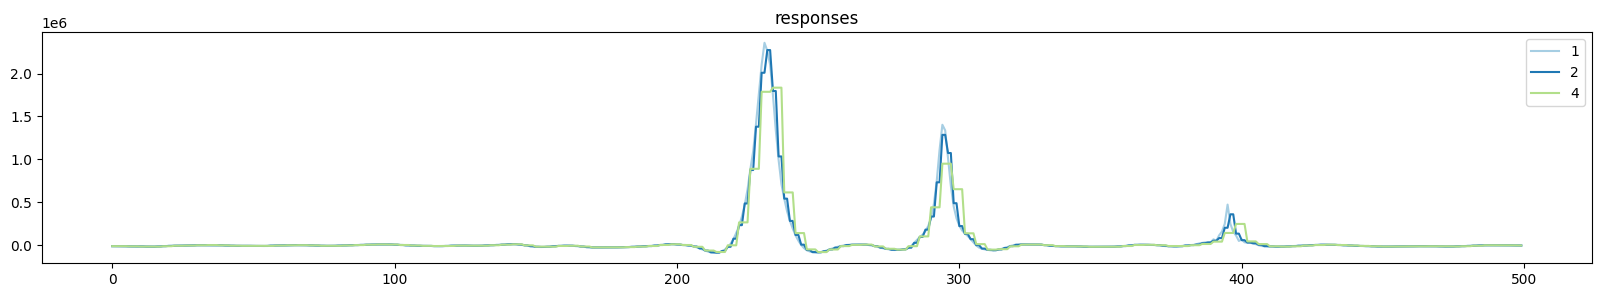

In [220]:
zoom = [1, 2, 4]

signal_dict = {}
for z in zoom:
    signal_dict[z] = downsample(signal_sum, z)

kernel_dict = {}
for z in zoom:
    kernel_dict[z] = downsample(kernel_sum, z)

response_dict = {}
for z in zoom:
    response_dict[z] = upsample(convolve(signal_dict[z], kernel_dict[z], mode='same', method='fft') * z, z)

pdict = {'offset': 6, 'figsize': (20,3)}
plot_1d([upsample(s, z) for z,s in signal_dict.items()], signal_dict.keys(), norm='log', title='signals', **pdict)
plot_1d([upsample(k, z) for z,k in kernel_dict.items()], kernel_dict.keys(), norm='linear', title='kernels', **pdict)
plot_1d(response_dict.values(), response_dict.keys(), norm='linear', title='responses', **pdict)

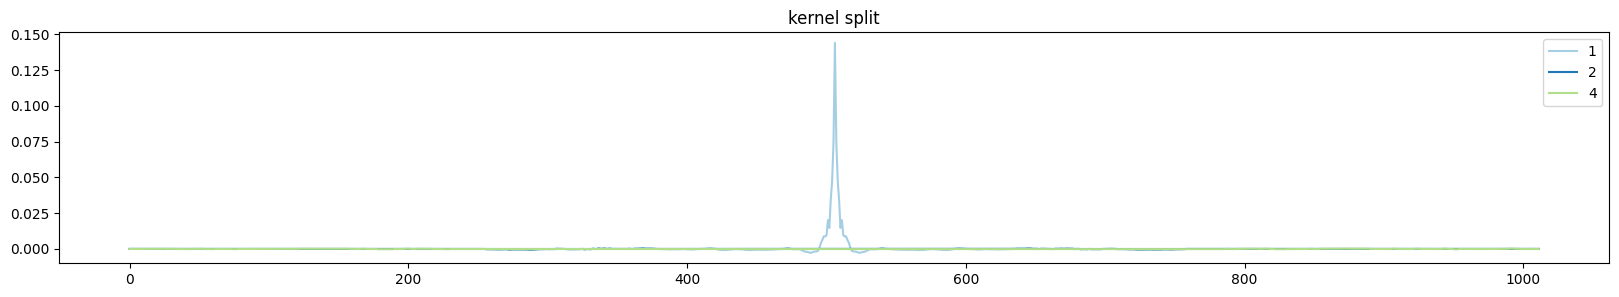

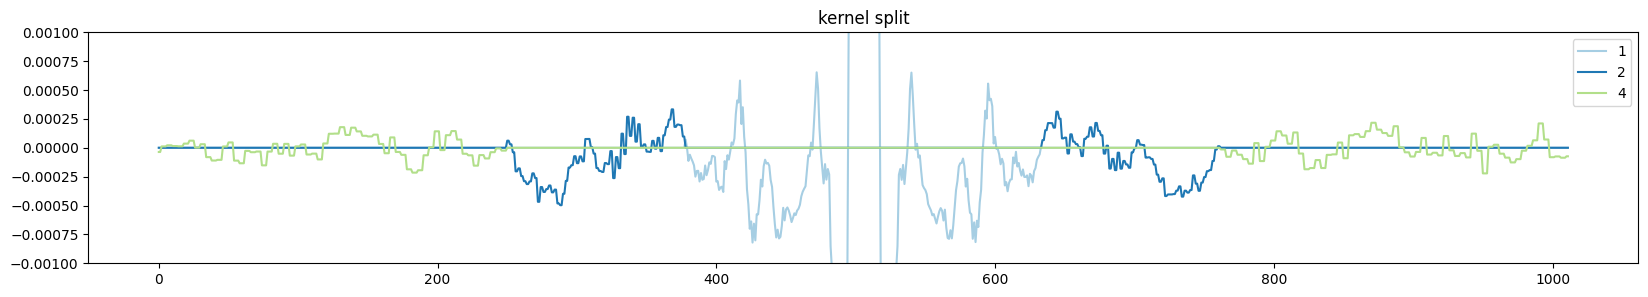

In [221]:
ksize = kernel_sum.size
zsize = ksize // max(zoom)

kernel_split = {}
for i,z in enumerate(zoom):
    ker = np.zeros_like(kernel_sum)
    if i == 0:
        slc_0 = slc_1 = slice(ksize//2 - zsize//2, ksize//2 + zsize//2)
    else:
        slc_0 = slice(ksize//2 - z*zsize//2, slc_0.start)
        slc_1 = slice(slc_1.stop, ksize//2 + z*zsize//2)
    ker[slc_0] = kernel_sum[slc_0]
    ker[slc_1] = kernel_sum[slc_1]
    kernel_split[z] = downsample(ker, z)

plot_1d([upsample(k, z) for z,k in kernel_split.items()], kernel_split.keys(), norm='linear', title='kernel split', **pdict)
plot_1d([upsample(k, z) for z,k in kernel_split.items()], kernel_split.keys(), norm='linear', title='kernel split', vmin=-0.001, vmax=0.001, **pdict)

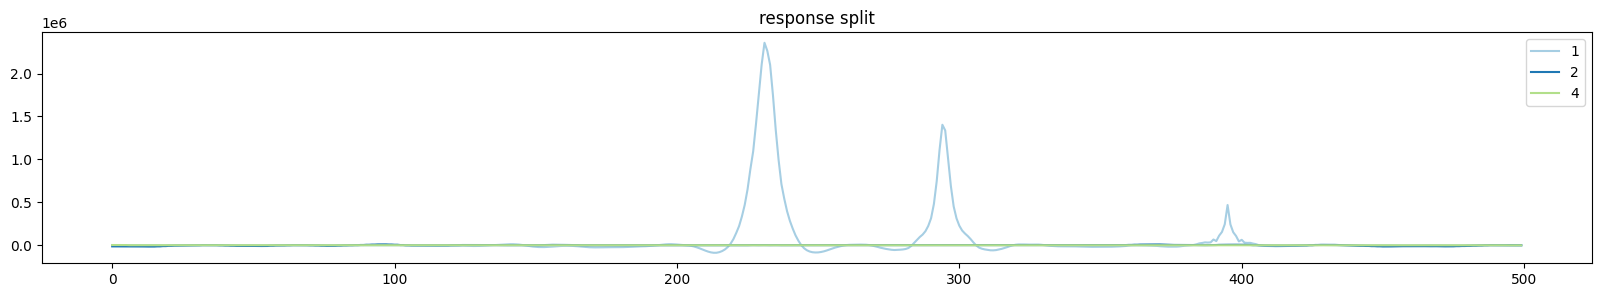

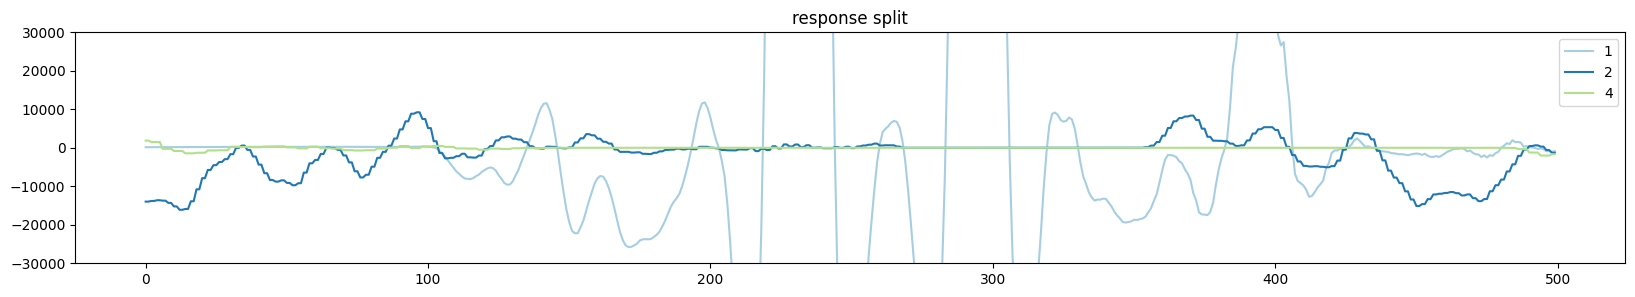

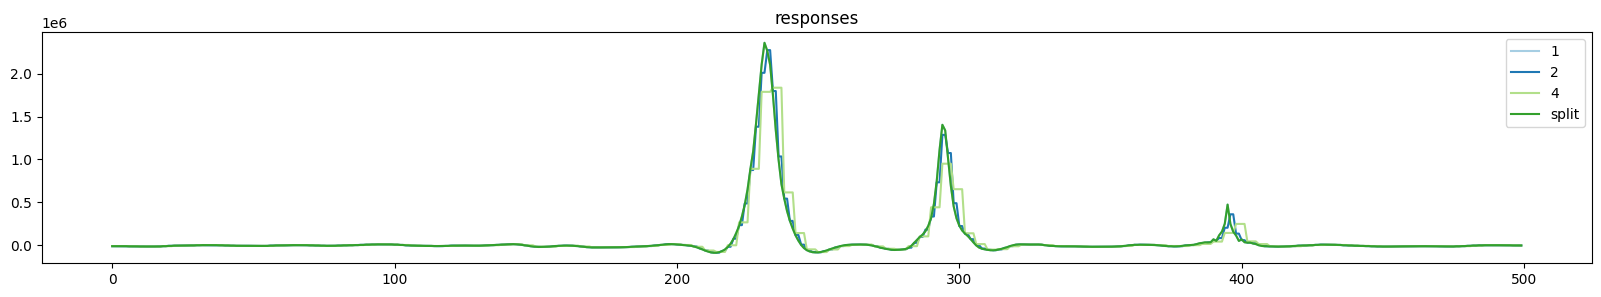

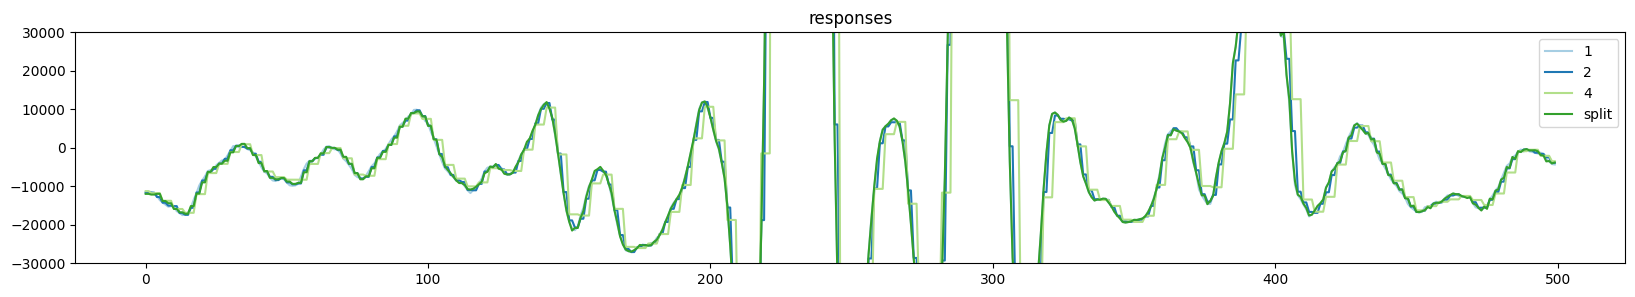

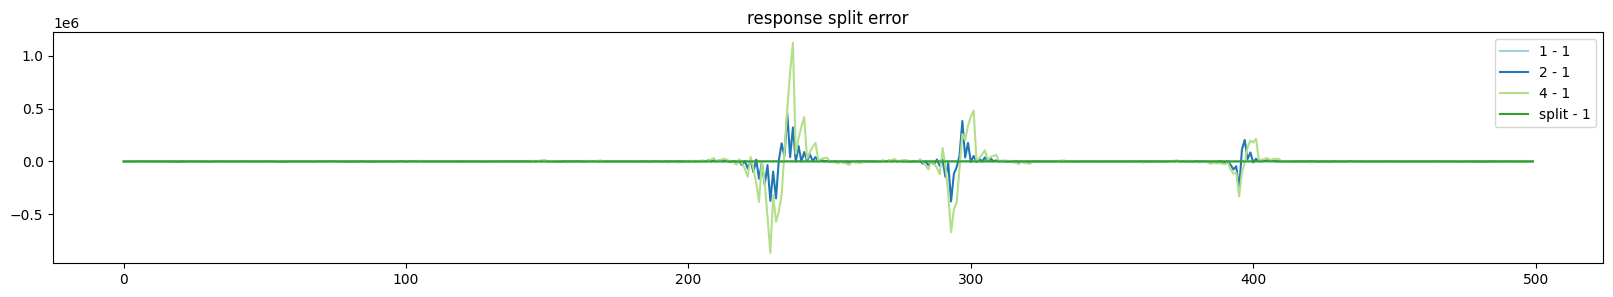

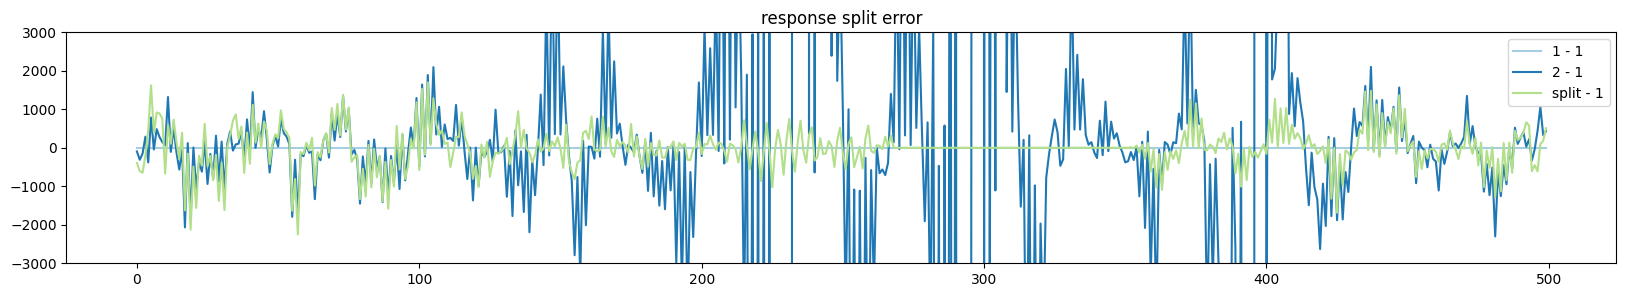

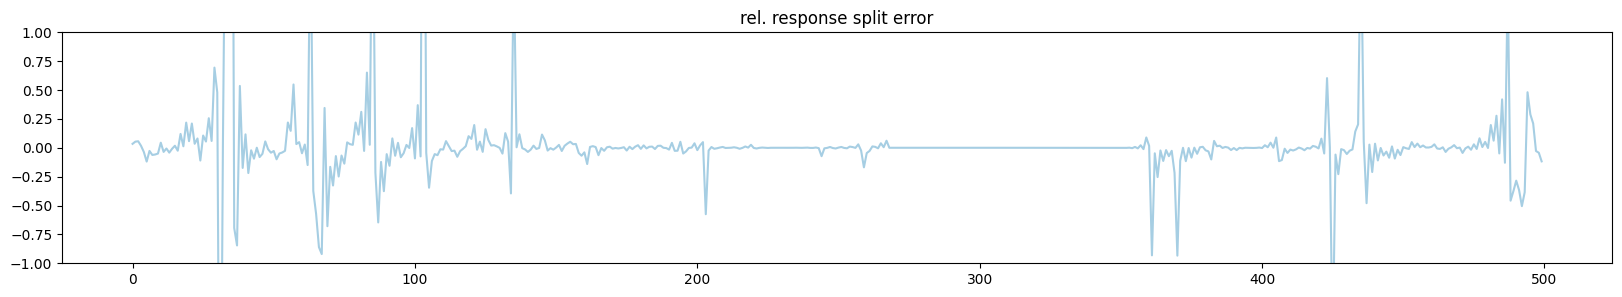

In [231]:
def multi_scale_kernel(signal_dict, kernel_split):

    response_split = kernel_split.copy()

    for z,k in kernel_split.items():
        response_split[z] = upsample(convolve(signal_dict[z], k, mode='same', method='fft') * z, z)

    return response_split

response_split = multi_scale_kernel(signal_dict, kernel_split)
response_sum = sum(response_split.values())

plot_1d(response_split.values(), response_split.keys(), norm='linear', title='response split', **pdict)
plot_1d(response_split.values(), response_split.keys(), norm='linear', title='response split', **pdict, vmin=-3e4, vmax=3e4)

rsp_val = list(response_dict.values()) + [response_sum]
rsp_key = list(response_dict.keys()) + ['split']

plot_1d(rsp_val, rsp_key, norm='linear', title='responses', **pdict)
plot_1d(rsp_val, rsp_key, norm='linear', title='responses', **pdict, vmin=-3e4, vmax=3e4)


plot_1d([rv - response_dict[1] for rv in rsp_val], [f'{rk} - 1' for rk in rsp_key], norm='linear', title='response split error', **pdict)
plot_1d([rv - response_dict[1] for rv in rsp_val[:2]+rsp_val[3:]], [f'{rk} - 1' for rk in rsp_key[:2]+rsp_key[3:]], norm='linear', 
        title='response split error', **pdict, vmin=-3e3, vmax=3e3)

plot_1d((response_sum - response_dict[1])/response_dict[1], norm='linear', title='rel. response split error', **pdict, vmin=-1, vmax=1)